# LSTM one-shot forecast diagnostic

This notebook loads the generated LSTM forecast artifacts, uses 2020-06-01 as the 96-step history window, predicts the next 24 steps once, and compares target values, direct LSTM generation, and canonical shared_data sequences.

In [1]:
from pathlib import Path
import os
import sys

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'configs' / 'profiles.py').exists():
    repo_root = repo_root.parent
if not (repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError('Failed to locate MADRL_ESS repo root containing configs/profiles.py.')
repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)
os.chdir(repo_root)


In [2]:
import json

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from configs.profiles import compose_experiment_config, project_root
from data.loaders.prosumer import ProsumerDataset
from predictors.lstm_forecaster import LSTMForecaster
from predictors.mainline_forecast import get_mainline_forecast_controls
from predictors.time_features import DEFAULT_LOCAL_TIMEZONE, coerce_timestamp_index
from predictors.training import (
    _load_signal_matrix_from_source as load_signal_matrix_from_source,
    ensure_lstm_artifacts,
    resolve_signal_csv_source,
    resolve_signal_physical_scale_from_source,
)
from scripts.utils.grid_notebook_workflow import apply_notebook_experiment_settings


In [3]:
root = project_root()
record_dir = root / 'notebooks' / 'record' / 'forecast' / 'lstm'
required_record_files = {
    'manifest': record_dir / 'manifest.json',
    'config_snapshot': record_dir / 'config_snapshot.json',
    'shared_data_record': record_dir / 'shared_data_record.json',
}
missing_record_files = [str(path) for path in required_record_files.values() if not path.exists()]
if missing_record_files:
    raise FileNotFoundError(
        'Missing generated LSTM forecast record file(s): '
        f'{missing_record_files}. Rerun notebooks/forecast/forecast_lstm.ipynb first.'
    )

manifest = json.loads(required_record_files['manifest'].read_text(encoding='utf-8'))
config_snapshot = json.loads(required_record_files['config_snapshot'].read_text(encoding='utf-8'))
shared_data_record = json.loads(required_record_files['shared_data_record'].read_text(encoding='utf-8'))
shared_data_dir = Path(shared_data_record['shared_data_dir'])
shared_test_dir = shared_data_dir / 'test'
required_shared_files = [
    shared_test_dir / 'manifest.json',
    shared_test_dir / 'wholesale_price_seq.npy',
    shared_test_dir / 'load_seq.npy',
    shared_test_dir / 'pv_seq.npy',
]
missing_shared_files = [str(path) for path in required_shared_files if not path.exists()]
if missing_shared_files:
    raise FileNotFoundError(
        'Missing generated shared_data file(s): '
        f'{missing_shared_files}. Rerun notebooks/forecast/forecast_lstm.ipynb first.'
    )

history_date = str(config_snapshot['test_start_date'])
forecast_steps = int(config_snapshot['future_horizon'])
device = 'cpu'

cfg = compose_experiment_config(
    forecast_type='lstm',
    data_dir=root / 'data',
    runtime_mode='performance',
    seed=0,
)
forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
forecast_controls['history_window'] = int(config_snapshot['history_window'])
apply_notebook_experiment_settings(
    cfg,
    prediction_mode='normal',
    test_start_date=config_snapshot['test_start_date'],
    test_end_date=config_snapshot['test_end_date'],
    agent_profiles=list(config_snapshot['agent_profiles']),
    agent_bus_ids=list(config_snapshot['agent_bus_ids']),
    load_scale=None,
    pv_scale=None,
    future_horizon=int(config_snapshot['future_horizon']),
    battery_controls=None,
    forecast_controls=forecast_controls,
    train_year=None,
    test_year=None,
)
cfg.forecast.auto_train_missing = False
cfg.runtime.device = device

expected_history_window = int(config_snapshot['history_window'])
history_window = int(cfg.forecast.history_window)
if history_window != expected_history_window:
    raise ValueError(f'Expected history_window={expected_history_window}, got {history_window}.')
if history_window <= 0:
    raise ValueError(f'history_window must be positive, got {history_window}.')
if int(cfg.env.future_horizon) != forecast_steps:
    raise ValueError(f'Expected future_horizon={forecast_steps}, got {cfg.env.future_horizon}.')

artifact_inventory = ensure_lstm_artifacts(cfg, device=device)
artifact_map = dict(artifact_inventory['artifacts'])
shared_manifest = json.loads((shared_test_dir / 'manifest.json').read_text(encoding='utf-8'))

display(pd.DataFrame([{
    'record_dir': str(record_dir),
    'shared_data_dir': str(shared_data_dir),
    'history_date': history_date,
    'history_window': history_window,
    'forecast_steps': forecast_steps,
    'device': device,
    'signals': ', '.join(cfg.forecast.target_signals),
}]))


,record_dir,shared_data_dir,history_date,history_window,forecast_steps,device,signals
0,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...,2020-06-01,96,24,cpu,"wholesale_price, load, pv"


In [4]:
def _normalize_local_timestamp_index(timestamps) -> pd.DatetimeIndex:
    timestamp_index = coerce_timestamp_index(timestamps)
    if getattr(timestamp_index, 'tz', None) is None:
        return timestamp_index.tz_localize(DEFAULT_LOCAL_TIMEZONE)
    return timestamp_index.tz_convert(DEFAULT_LOCAL_TIMEZONE)


def _as_2d(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float32)
    return values.reshape(-1, 1) if values.ndim == 1 else values


def _load_test_signal(signal_name: str):
    source = resolve_signal_csv_source(root / 'data', signal_name, cfg=cfg)
    if source is None:
        raise FileNotFoundError(f'No test signal source is configured for {signal_name!r}.')
    frame, values, value_columns = load_signal_matrix_from_source(source, signal_name, split='test')
    timestamp_index = _normalize_local_timestamp_index(frame['timestamp'].tolist())
    frame = frame.copy().reset_index(drop=True)
    frame['timestamp'] = timestamp_index
    return source, frame, _as_2d(values), tuple(value_columns)


def _select_history_and_target(frame: pd.DataFrame, values: np.ndarray):
    timestamp_index = _normalize_local_timestamp_index(frame['timestamp'].tolist())
    history_day_mask = timestamp_index.date == pd.Timestamp(history_date).date()
    history_day_positions = np.flatnonzero(history_day_mask)
    if history_day_positions.size == 0:
        raise ValueError(f'No rows found for history_date={history_date}.')
    expected_day_positions = np.arange(history_day_positions[0], history_day_positions[0] + history_day_positions.size)
    if not np.array_equal(history_day_positions, expected_day_positions):
        raise ValueError(f'history_date={history_date} is not a contiguous local-day window.')
    target_start = int(history_day_positions[-1]) + 1
    history_start = target_start - history_window
    if history_start < 0:
        raise ValueError(
            f'Not enough rows before prediction boundary for history_window={history_window}: '
            f'need {history_window}, available {target_start}.'
        )
    history_positions = np.arange(history_start, target_start)
    target_end = target_start + forecast_steps
    if target_end > len(frame):
        raise ValueError(
            f'Not enough target rows after history_date={history_date}: '
            f'need {forecast_steps}, available {len(frame) - target_start}.'
        )
    target_positions = np.arange(target_start, target_end)
    return {
        'history_positions': history_positions,
        'target_positions': target_positions,
        'history_values': values[history_positions],
        'target_values': values[target_positions],
        'history_timestamps': timestamp_index[history_positions].tolist(),
        'target_timestamps': timestamp_index[target_positions],
    }


def _build_forecaster(signal_name: str) -> LSTMForecaster:
    if signal_name not in artifact_map:
        raise FileNotFoundError(
            f'Missing LSTM artifact bundle for {signal_name!r}. '
            'Rerun notebooks/forecast/forecast_lstm.ipynb first.'
        )
    return LSTMForecaster.from_signal_artifacts({signal_name: artifact_map[signal_name]}, device=device)


def _load_history_component_signals(source, history_positions: np.ndarray) -> dict[str, np.ndarray]:
    dataset_kwargs = dict(source.dataset_kwargs['test'])
    dataset = ProsumerDataset(**dataset_kwargs)
    return {
        key: np.asarray(value, dtype=np.float32)[history_positions]
        for key, value in dataset._signals.items()
        if str(key).startswith('load_')
    }


def _load_component_signals(source, positions: np.ndarray) -> dict[str, np.ndarray]:
    dataset_kwargs = dict(source.dataset_kwargs['test'])
    dataset = ProsumerDataset(**dataset_kwargs)
    return {
        key: np.asarray(value, dtype=np.float32)[positions]
        for key, value in dataset._signals.items()
        if str(key).startswith('load_')
    }


def _episode_meta(source, signal_name: str) -> dict[str, np.ndarray]:
    scale = resolve_signal_physical_scale_from_source(source, signal_name, split='test')
    if scale is None:
        return {}
    if signal_name == 'load':
        return {'load_scale': np.asarray(scale, dtype=np.float32)}
    if signal_name == 'pv':
        return {'pv_peak_kw': np.asarray(scale, dtype=np.float32)}
    return {}


def _predict_next_24(signal_name: str, source, window: dict[str, object]) -> np.ndarray:
    forecaster = _build_forecaster(signal_name)
    meta = _episode_meta(source, signal_name)
    if signal_name == 'load':
        forecaster.set_episode(
            _load_history_component_signals(source, window['history_positions']),
            episode_meta=meta,
        )
    elif meta:
        forecaster.set_episode(window['history_values'], episode_meta=meta)
    prediction = forecaster.predict(
        window['history_values'],
        horizon=forecast_steps + 1,
        signal_name=signal_name,
        history_timestamps=window['history_timestamps'],
    )
    prediction = np.asarray(prediction, dtype=np.float32)
    if prediction.ndim == 1:
        return prediction[1:forecast_steps + 1].reshape(-1, 1)
    return prediction[:, 1:forecast_steps + 1].T.astype(np.float32, copy=False)


def _predict_one_step_ahead_24(signal_name: str, source, frame: pd.DataFrame, values: np.ndarray, window: dict[str, object]) -> np.ndarray:
    forecaster = _build_forecaster(signal_name)
    meta = _episode_meta(source, signal_name)
    values = _as_2d(values)
    timestamp_index = _normalize_local_timestamp_index(frame['timestamp'].tolist())
    rows = []
    for target_position in np.asarray(window['target_positions'], dtype=np.int64):
        history_positions = np.arange(int(target_position) - history_window, int(target_position))
        if history_positions[0] < 0:
            raise ValueError(f'Not enough history before target position {int(target_position)} for signal={signal_name!r}.')
        history_values = values[history_positions]
        if signal_name == 'load':
            forecaster.set_episode(_load_component_signals(source, history_positions), episode_meta=meta)
        elif meta:
            forecaster.set_episode(history_values, episode_meta=meta)
        prediction = np.asarray(
            forecaster.predict(
                history_values,
                horizon=2,
                signal_name=signal_name,
                history_timestamps=timestamp_index[history_positions].tolist(),
            ),
            dtype=np.float32,
        )
        rows.append(prediction[1:2] if prediction.ndim == 1 else prediction[:, 1].astype(np.float32))
    return np.stack(rows, axis=0).astype(np.float32)


def _shared_episode_index() -> int:
    matches = [
        index
        for index, episode in enumerate(shared_manifest['episodes'])
        if str(episode.get('first_local_date')) == history_date
    ]
    if len(matches) != 1:
        raise ValueError(f'Expected one shared_data episode for {history_date}, got {matches}.')
    return int(matches[0])


def _shared_data_next_24(signal_name: str, series_count: int) -> np.ndarray:
    episode_idx = _shared_episode_index()
    sequence_length = int(shared_manifest['sequence_length'])
    episode_length = int(shared_manifest['episode_length'])
    step_idx = episode_length - 1
    if step_idx < 0:
        raise ValueError(f'shared_data episode_length={episode_length} cannot provide a prediction boundary.')
    if step_idx >= episode_length:
        raise ValueError(f'shared_data episode_length={episode_length} is shorter than step_idx={step_idx}.')
    if sequence_length < forecast_steps + 1:
        raise ValueError(f'shared_data sequence_length={sequence_length} is shorter than {forecast_steps + 1}.')
    if signal_name == 'wholesale_price':
        values = np.load(shared_test_dir / 'wholesale_price_seq.npy')[episode_idx, step_idx, 1:forecast_steps + 1]
        values = values.reshape(-1, 1)
    elif signal_name == 'load':
        values = np.load(shared_test_dir / 'load_seq.npy')[episode_idx, step_idx, :, 1:forecast_steps + 1].T
    elif signal_name == 'pv':
        values = np.load(shared_test_dir / 'pv_seq.npy')[episode_idx, step_idx, :, 1:forecast_steps + 1].T
    else:
        raise ValueError(f'Unsupported shared_data signal {signal_name!r}.')
    values = np.asarray(values, dtype=np.float32)
    expected_shape = (forecast_steps, int(series_count))
    if values.shape != expected_shape:
        raise ValueError(f'{signal_name} shared_data shape mismatch: expected {expected_shape}, got {values.shape}.')
    return values


In [5]:
records = []
for signal_name in ('wholesale_price', 'load', 'pv'):
    source, frame, values, value_columns = _load_test_signal(signal_name)
    window = _select_history_and_target(frame, values)
    generated_lstm = _predict_next_24(signal_name, source, window)
    one_step_ahead = _predict_one_step_ahead_24(signal_name, source, frame, values, window)
    shared_data = _shared_data_next_24(signal_name, series_count=len(value_columns))
    target = np.asarray(window['target_values'], dtype=np.float32)
    timestamps = _normalize_local_timestamp_index(window['target_timestamps'])

    if generated_lstm.shape != target.shape:
        raise ValueError(f'{signal_name} generated_lstm shape mismatch: expected {target.shape}, got {generated_lstm.shape}.')
    if one_step_ahead.shape != target.shape:
        raise ValueError(f'{signal_name} one_step_ahead shape mismatch: expected {target.shape}, got {one_step_ahead.shape}.')

    for column_idx, series_name in enumerate(value_columns):
        for row_idx, timestamp in enumerate(timestamps):
            records.append({
                'timestamp': timestamp,
                'signal_name': signal_name,
                'series_name': series_name,
                'target': float(target[row_idx, column_idx]),
                'generated_lstm': float(generated_lstm[row_idx, column_idx]),
                'one_step_ahead': float(one_step_ahead[row_idx, column_idx]),
                'shared_data': float(shared_data[row_idx, column_idx]),
            })

plot_df = pd.DataFrame.from_records(records)
plot_df['abs_error_generated'] = (plot_df['target'] - plot_df['generated_lstm']).abs()
plot_df['abs_error_one_step'] = (plot_df['target'] - plot_df['one_step_ahead']).abs()
plot_df['abs_delta_generated_shared'] = (plot_df['generated_lstm'] - plot_df['shared_data']).abs()
plot_df['abs_delta_one_step_generated'] = (plot_df['one_step_ahead'] - plot_df['generated_lstm']).abs()
plot_df['abs_delta_one_step_shared'] = (plot_df['one_step_ahead'] - plot_df['shared_data']).abs()

summary_df = (
    plot_df.groupby(['signal_name', 'series_name'], as_index=False)
    .agg(
        prediction_start=('timestamp', 'min'),
        prediction_end=('timestamp', 'max'),
        rows=('timestamp', 'size'),
        mae_target_vs_generated=('abs_error_generated', 'mean'),
        mae_target_vs_one_step=('abs_error_one_step', 'mean'),
        max_generated_vs_shared_delta=('abs_delta_generated_shared', 'max'),
        max_one_step_vs_generated_delta=('abs_delta_one_step_generated', 'max'),
        max_one_step_vs_shared_delta=('abs_delta_one_step_shared', 'max'),
    )
)
display(summary_df)
display(plot_df.head(12))


,signal_name,series_name,prediction_start,prediction_end,rows,mae_target_vs_generated,mae_target_vs_one_step,max_generated_vs_shared_delta,max_one_step_vs_generated_delta,max_one_step_vs_shared_delta
0,load,load_SFH12,2020-06-02 00:00:00+02:00,2020-06-02 05:45:00+02:00,24,1.729421,1.049783,0.000086,8.213926,8.213953
1,load,load_SFH18,2020-06-02 00:00:00+02:00,2020-06-02 05:45:00+02:00,24,1.376404,0.560159,0.000122,3.014280,3.014355
2,load,load_SFH20,2020-06-02 00:00:00+02:00,2020-06-02 05:45:00+02:00,24,4.309504,6.616357,0.000286,71.027161,71.027358
3,pv,pv_SFH12,2020-06-02 00:00:00+02:00,2020-06-02 05:45:00+02:00,24,0.017573,0.030654,0.012933,0.080705,0.079292
4,pv,pv_SFH18,2020-06-02 00:00:00+02:00,2020-06-02 05:45:00+02:00,24,0.017573,0.030654,0.012933,0.080705,0.079292
5,pv,pv_SFH20,2020-06-02 00:00:00+02:00,2020-06-02 05:45:00+02:00,24,0.017573,0.030654,0.012933,0.080705,0.079292
6,wholesale_price,wholesale_price,2020-06-02 00:00:00+02:00,2020-06-02 05:45:00+02:00,24,0.004935,0.001752,0.000004,0.010745,0.010749


,timestamp,signal_name,series_name,target,generated_lstm,one_step_ahead,shared_data,abs_error_generated,abs_error_one_step,abs_delta_generated_shared,abs_delta_one_step_generated,abs_delta_one_step_shared
0,2020-06-02 00:00:00+02:00,wholesale_price,wholesale_price,0.01808,0.022077,0.022077,0.022077,0.003997,0.003997,2.048910e-08,0.000000,2.048910e-08
1,2020-06-02 00:15:00+02:00,wholesale_price,wholesale_price,0.01808,0.021098,0.020617,0.021097,0.003018,0.002537,2.365559e-07,0.000480,4.798286e-04
2,2020-06-02 00:30:00+02:00,wholesale_price,wholesale_price,0.01808,0.020413,0.019798,0.020413,0.002333,0.001718,9.499490e-08,0.000615,6.154031e-04
3,2020-06-02 00:45:00+02:00,wholesale_price,wholesale_price,0.01808,0.019512,0.019647,0.019512,0.001432,0.001567,8.381903e-08,0.000135,1.349095e-04
4,2020-06-02 01:00:00+02:00,wholesale_price,wholesale_price,0.01633,0.019021,0.019758,0.019021,0.002691,0.003428,1.657754e-07,0.000738,7.377136e-04
5,2020-06-02 01:15:00+02:00,wholesale_price,wholesale_price,0.01633,0.018294,0.018832,0.018295,0.001964,0.002502,3.967434e-07,0.000537,5.369615e-04
6,2020-06-02 01:30:00+02:00,wholesale_price,wholesale_price,0.01633,0.017476,0.018291,0.017477,0.001146,0.001961,4.228204e-07,0.000814,8.138642e-04
7,2020-06-02 01:45:00+02:00,wholesale_price,wholesale_price,0.01633,0.017350,0.018172,0.017350,0.001020,0.001842,6.724149e-07,0.000823,8.218307e-04
8,2020-06-02 02:00:00+02:00,wholesale_price,wholesale_price,0.01499,0.017092,0.018090,0.017093,0.002102,0.003100,1.175329e-06,0.000998,9.965133e-04
9,2020-06-02 02:15:00+02:00,wholesale_price,wholesale_price,0.01499,0.016947,0.017139,0.016949,0.001957,0.002149,1.190230e-06,0.000192,1.905784e-04


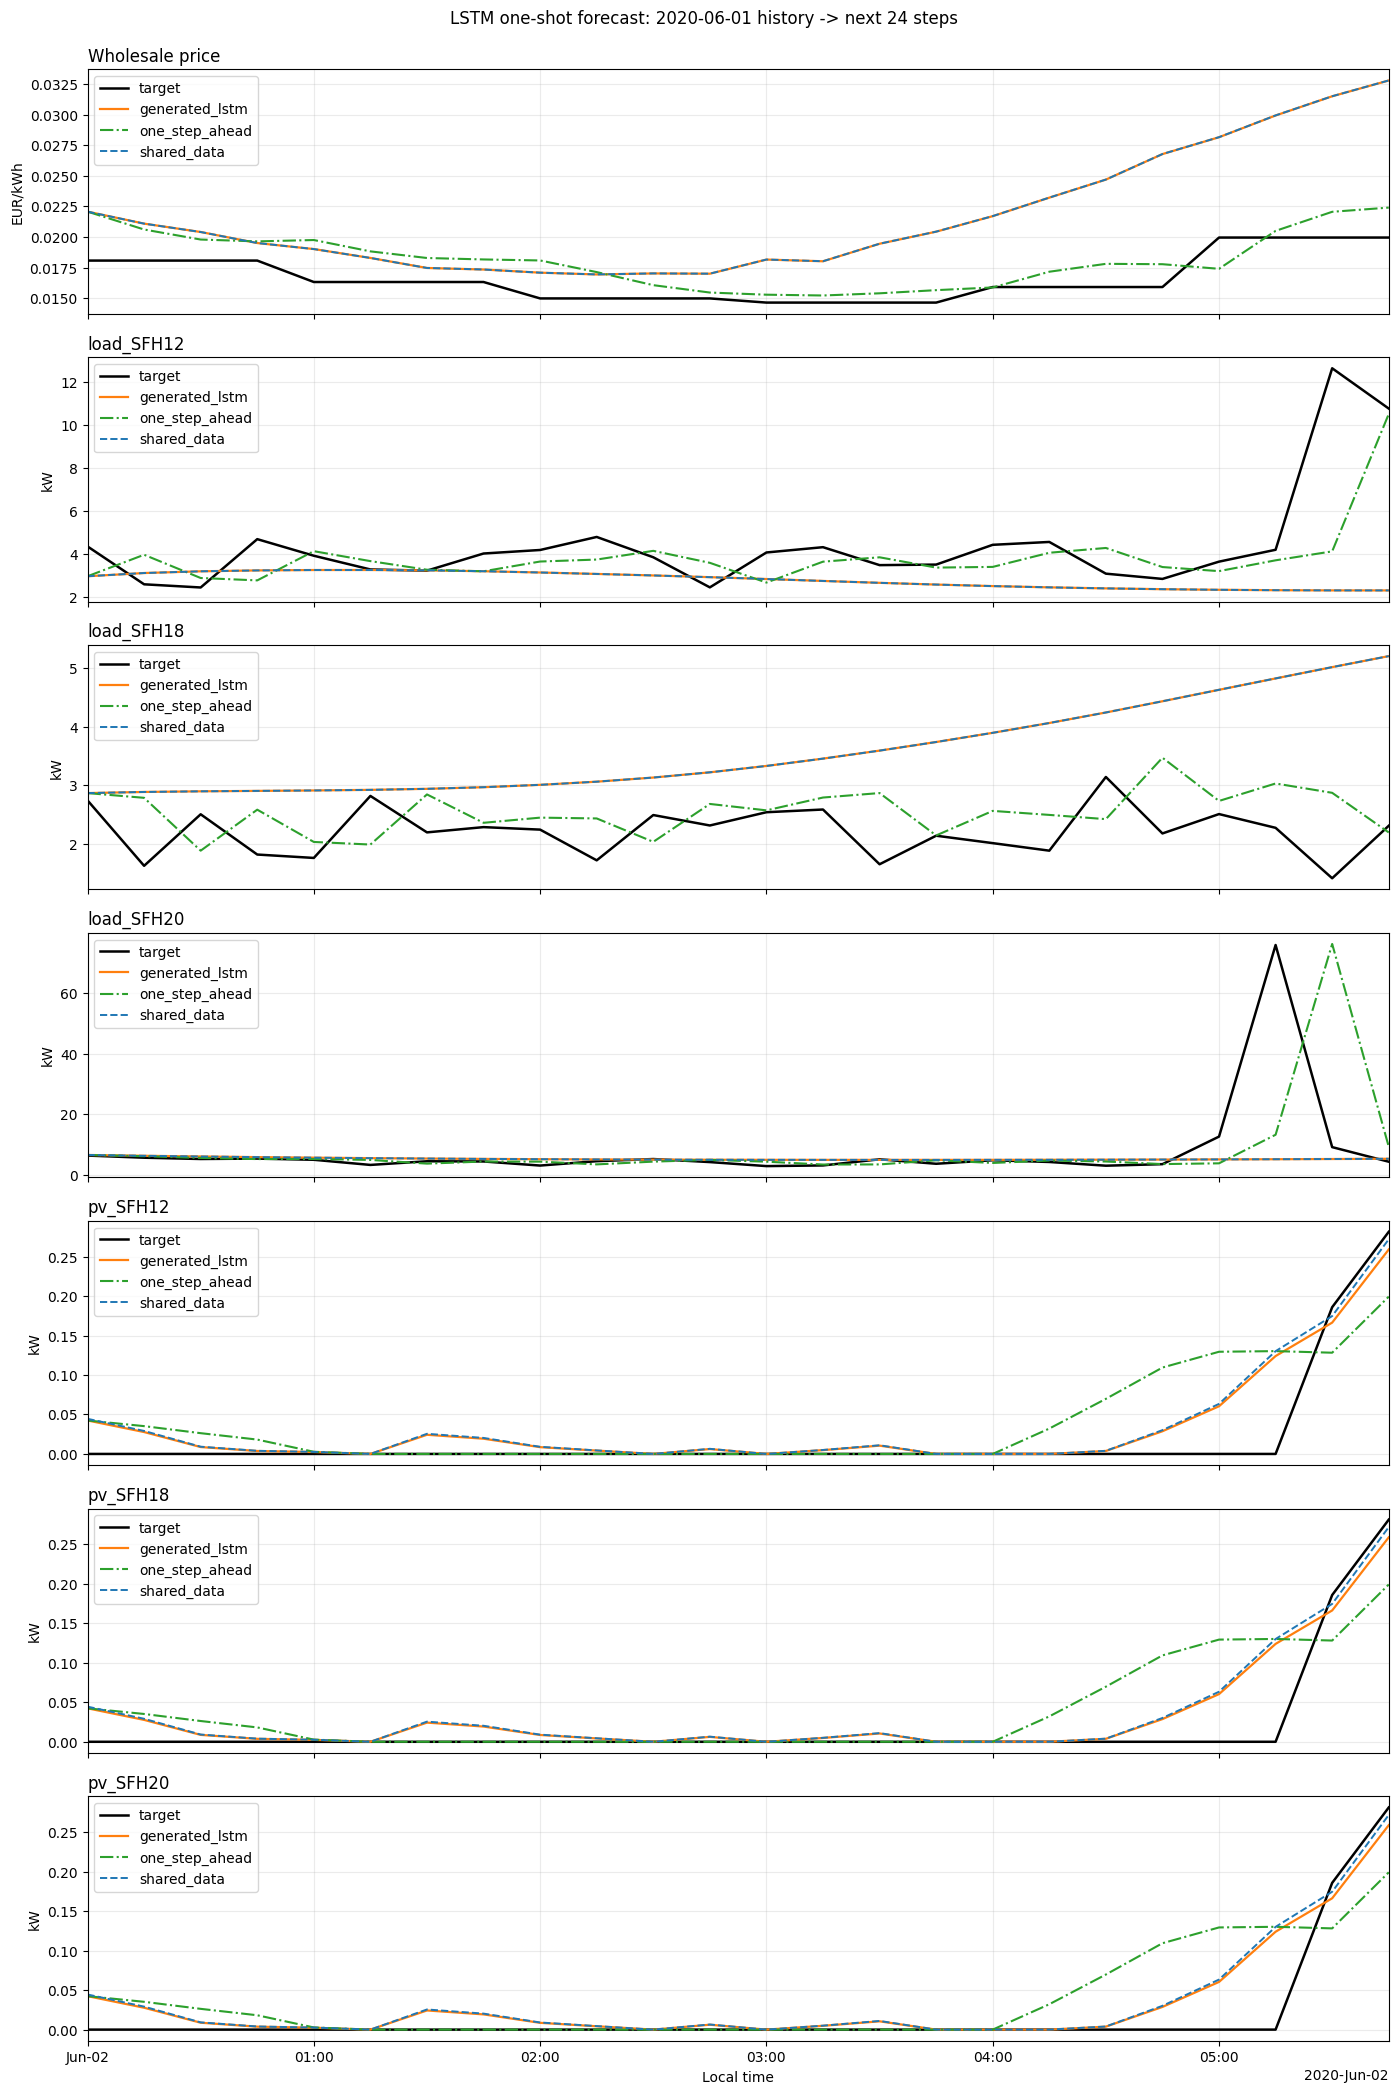

In [6]:
series_order = (
    ['wholesale_price']
    + [series for series in plot_df.loc[plot_df['signal_name'] == 'load', 'series_name'].drop_duplicates()]
    + [series for series in plot_df.loc[plot_df['signal_name'] == 'pv', 'series_name'].drop_duplicates()]
)
n_axes = len(series_order)
fig, axes = plt.subplots(n_axes, 1, figsize=(14, max(3.0 * n_axes, 6.0)), sharex=True)
if n_axes == 1:
    axes = [axes]

for axis, series_name in zip(axes, series_order):
    if series_name == 'wholesale_price':
        series_df = plot_df.loc[plot_df['signal_name'] == 'wholesale_price'].sort_values('timestamp')
        ylabel = 'EUR/kWh'
        title = 'Wholesale price'
    else:
        series_df = plot_df.loc[plot_df['series_name'] == series_name].sort_values('timestamp')
        ylabel = 'kW'
        title = series_name

    x_values = pd.to_datetime(series_df['timestamp']).dt.tz_convert(DEFAULT_LOCAL_TIMEZONE).dt.tz_localize(None)
    axis.plot(x_values, series_df['target'], label='target', color='black', linewidth=1.8)
    axis.plot(x_values, series_df['generated_lstm'], label='generated_lstm', color='tab:orange', linewidth=1.6)
    axis.plot(x_values, series_df['one_step_ahead'], label='one_step_ahead', color='tab:green', linestyle='-.', linewidth=1.5)
    axis.plot(x_values, series_df['shared_data'], label='shared_data', color='tab:blue', linestyle='--', linewidth=1.4)
    axis.set_title(title, loc='left')
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.25)
    axis.legend(loc='best')

plot_start = pd.to_datetime(plot_df['timestamp'].min()).tz_convert(DEFAULT_LOCAL_TIMEZONE).tz_localize(None)
plot_end = pd.to_datetime(plot_df['timestamp'].max()).tz_convert(DEFAULT_LOCAL_TIMEZONE).tz_localize(None)
axes[-1].set_xlim(plot_start, plot_end)
axes[-1].set_xlabel('Local time')
axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[-1].xaxis.get_major_locator()))
fig.suptitle('LSTM one-shot forecast: 2020-06-01 history -> next 24 steps', y=0.995)
fig.tight_layout()
plt.show()
